In [1]:
import pandas as pd

pacientes = pd.read_csv('../data/raw/pacientes.csv')
internacoes = pd.read_csv('../data/raw/internacoes.csv')
procedimentos = pd.read_csv('../data/raw/procedimentos.csv')
faturamento = pd.read_csv('../data/raw/faturamento.csv')

In [2]:
pacientes.info()
internacoes.info()
faturamento.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id_paciente  100 non-null    int64 
 1   nome         100 non-null    object
 2   idade        100 non-null    int64 
 3   sexo         100 non-null    object
dtypes: int64(2), object(2)
memory usage: 3.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id_internacao  200 non-null    int64 
 1   id_paciente    200 non-null    int64 
 2   data_entrada   200 non-null    object
 3   data_saida     200 non-null    object
 4   setor          200 non-null    object
dtypes: int64(2), object(3)
memory usage: 7.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 592 entries, 0 to 591
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtyp

In [3]:
pacientes.head()
internacoes.head()
faturamento.head()

,id_internacao,id_procedimento,quantidade,custo_total
0,1,2,1,80
1,1,1,2,300
2,1,5,3,900
3,2,3,2,400
4,3,4,1,5000


In [4]:
df = faturamento.merge(internacoes, on='id_internacao', how='left') \
                .merge(pacientes, on='id_paciente', how='left') \
                .merge(procedimentos, on='id_procedimento', how='left')

df.head()

,id_internacao,id_procedimento,quantidade,custo_total,id_paciente,data_entrada,data_saida,setor,nome,idade,sexo,descricao,custo_unitario
0,1,2,1,80,65,2024-09-20,2024-09-29,Centro Cirúrgico,Paciente_65,20,F,Exame de sangue,80
1,1,1,2,300,65,2024-09-20,2024-09-29,Centro Cirúrgico,Paciente_65,20,F,Consulta médica,150
2,1,5,3,900,65,2024-09-20,2024-09-29,Centro Cirúrgico,Paciente_65,20,F,Diária hospitalar,300
3,2,3,2,400,68,2024-05-12,2024-05-13,Emergência,Paciente_68,82,F,Raio-X,200
4,3,4,1,5000,90,2024-07-21,2024-07-27,Enfermaria,Paciente_90,7,F,Cirurgia,5000


In [5]:
df['data_entrada'] = pd.to_datetime(df['data_entrada'])
df['data_saida'] = pd.to_datetime(df['data_saida'])

df['tempo_internacao'] = (df['data_saida'] - df['data_entrada']).dt.days

In [6]:
custo_paciente = df.groupby('id_paciente')['custo_total'].sum().sort_values(ascending=False)

custo_paciente.head()

id_paciente
21    70060
11    66010
69    60020
90    52850
29    42780
Name: custo_total, dtype: int64

In [7]:
custo_setor = df.groupby('setor')['custo_total'].sum().sort_values(ascending=False)

custo_setor

setor
Emergência          507690
UTI                 338580
Centro Cirúrgico    332360
Enfermaria          308440
Name: custo_total, dtype: int64

In [8]:
df['tempo_internacao'].mean()

np.float64(7.70777027027027)

In [9]:
df[['tempo_internacao', 'custo_total']].corr()

,tempo_internacao,custo_total
tempo_internacao,1.000000,0.003748
custo_total,0.003748,1.000000


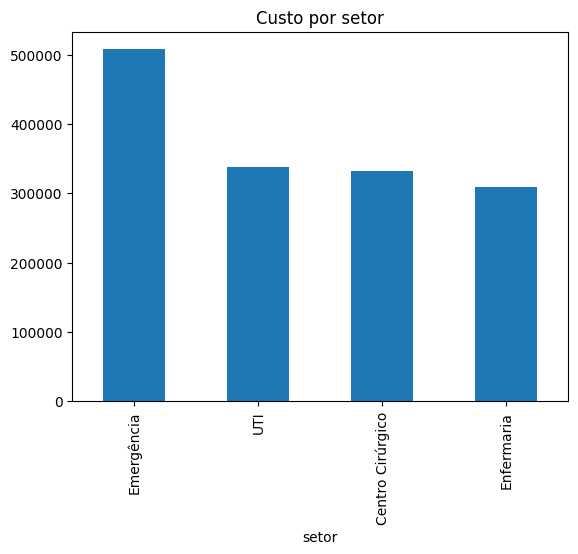

In [10]:
import matplotlib.pyplot as plt

custo_setor.plot(kind='bar')
plt.title('Custo por setor')
plt.show()

In [11]:
print(len(pacientes))
print(len(internacoes))
print(len(faturamento))

100
200
592


In [12]:
df['custo_medio_item'] = df['custo_total'] / df['quantidade']

In [13]:
df['ano'] = df['data_entrada'].dt.year
df['mes'] = df['data_entrada'].dt.month
df['dia'] = df['data_entrada'].dt.day

In [14]:
def faixa_etaria(idade):
    if idade <= 12:
        return 'Criança'
    elif idade <= 18:
        return 'Adolescente'
    elif idade <= 60:
        return 'Adulto'
    else:
        return 'Idoso'

df['faixa_etaria'] = df['idade'].apply(faixa_etaria)

In [15]:
custo_internacao = df.groupby('id_internacao')['custo_total'].sum().reset_index()
custo_internacao.columns = ['id_internacao', 'custo_total_internacao']

df = df.merge(custo_internacao, on='id_internacao')

In [16]:
#MODELAGEM DE DADOS

In [17]:
df = pd.read_csv('../data/processed/dados_tratados.csv')

In [23]:
'faixa_etaria' in df.columns

True

In [28]:
df = pd.read_csv('../data/processed/dados_tratados.csv')

print(df.columns)

Index(['id_internacao', 'id_procedimento', 'quantidade', 'custo_total',
       'id_paciente', 'data_entrada', 'data_saida', 'setor', 'nome', 'idade',
       'sexo', 'descricao', 'custo_unitario', 'tempo_internacao',
       'custo_medio_item', 'ano', 'mes', 'dia', 'faixa_etaria'],
      dtype='object')


In [24]:
dim_paciente = df[['id_paciente', 'idade', 'sexo', 'faixa_etaria']].drop_duplicates()

In [25]:
dim_procedimento = df[['id_procedimento', 'descricao', 'custo_unitario']].drop_duplicates()

In [26]:
dim_setor = df[['setor']].drop_duplicates().reset_index(drop=True)
dim_setor['id_setor'] = dim_setor.index + 1

In [29]:
dim_tempo = df[['data_entrada', 'ano', 'mes', 'dia']].drop_duplicates()
dim_tempo.columns = ['data', 'ano', 'mes', 'dia']

In [30]:
fato = df.merge(dim_setor, on='setor')

fato_faturamento = fato[[
    'id_internacao',
    'id_paciente',
    'id_procedimento',
    'id_setor',
    'custo_total',
    'quantidade',
    'tempo_internacao'
]]

In [31]:
dim_paciente.to_csv('../data/processed/dim_paciente.csv', index=False)
dim_procedimento.to_csv('../data/processed/dim_procedimento.csv', index=False)
dim_setor.to_csv('../data/processed/dim_setor.csv', index=False)
dim_tempo.to_csv('../data/processed/dim_tempo.csv', index=False)
fato_faturamento.to_csv('../data/processed/fato_faturamento.csv', index=False)